# MANOVA: Comparing Multiple Learning Outcomes across Teaching Methods

This Notebook applies Multivariate Analysis of Variance (MANOVA) to examine whether teaching methods differ across multiple learning outcomes simultaneously.

# 多変量分散分析：教育方法による複数の学習成果を比較する

このNotebookでは、多変量分散分析（MANOVA）を使って、教育方法によって複数の学習成果が総合的に異なるかを分析します。

## 1. Learning Objectives / 学習目標

- Understand the difference between ANOVA and MANOVA
- Explore multiple dependent variables jointly
- Perform MANOVA with `statsmodels`
- Interpret Pillai's Trace and Wilks' Lambda
- Conduct follow-up ANOVAs and multiple-testing correction
- Examine effect sizes and assumptions

- ANOVAとMANOVAの違いを理解する
- 複数の目的変数を同時に分析する意味を理解する
- `statsmodels`でMANOVAを実行する
- Pillai's TraceとWilks' Lambdaを中心に結果を読む
- 個別ANOVAと多重検定補正を行う
- 効果量・前提条件を確認する

## 2. Use Case / ユースケース

A school compares three teaching methods: Traditional, Blended, and Project-Based.

Students are evaluated on Mathematics, Reading, and Problem Solving.

**Question:** Do teaching methods affect the overall pattern of learning outcomes?

ある学校で3種類の教育方法を比較します。目的変数は数学・読解・問題解決です。

**問い：教育方法によって、複数の学習成果を総合したパターンに違いがあるか？**

## 3. ANOVA vs MANOVA / ANOVAとMANOVA

| Method | Dependent variables |
|---|---|
| ANOVA | One |
| MANOVA | Multiple |

ANOVA evaluates one outcome at a time. MANOVA first asks whether groups differ in the multivariate outcome space.

ANOVAは1つの目的変数について群間差を検定します。MANOVAは複数の目的変数をまとめ、平均ベクトルの群間差を検定します。

## 4. Import Libraries / ライブラリの読み込み

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import levene
from statsmodels.formula.api import ols
from statsmodels.multivariate.manova import MANOVA
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multitest import multipletests
pd.set_option("display.max_columns", None)

## 5. Load the Dataset / データの読み込み

In [2]:
paths=[Path("../data/learning_outcomes.csv"),Path("10_manova/data/learning_outcomes.csv"),Path("data/learning_outcomes.csv")]
data_path=next((p for p in paths if p.exists()),None)
if data_path is None: raise FileNotFoundError("learning_outcomes.csv was not found.")
df=pd.read_csv(data_path)
df.head()

,student_id,teaching_method,math_score,reading_score,problem_solving_score
0,S001,Traditional,67,75,63
1,S002,Traditional,73,68,55
2,S003,Traditional,70,72,66
3,S004,Traditional,70,77,76
4,S005,Traditional,66,70,72


## 6. Understand the Dataset / データの理解

In [3]:
print("Shape:",df.shape)
df.info()

Shape: (150, 5)
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   student_id             150 non-null    str  
 1   teaching_method        150 non-null    str  
 2   math_score             150 non-null    int64
 3   reading_score          150 non-null    int64
 4   problem_solving_score  150 non-null    int64
dtypes: int64(3), str(2)
memory usage: 6.0 KB


In [4]:
df.isna().sum()

student_id               0
teaching_method          0
math_score               0
reading_score            0
problem_solving_score    0
dtype: int64

In [5]:
df["teaching_method"].value_counts()

teaching_method
Traditional      50
Blended          50
Project_Based    50
Name: count, dtype: int64

## 7. Descriptive Statistics / 教育方法別の記述統計

In [6]:
outcomes=["math_score","reading_score","problem_solving_score"]
df.groupby("teaching_method")[outcomes].agg(["mean","std"]).round(2)

math_score       reading_score       problem_solving_score  \
                      mean   std          mean   std                  mean   
teaching_method                                                              
Blended              76.56  6.24         76.72  6.20                 75.64   
Project_Based        73.30  6.28         76.50  7.29                 80.18   
Traditional          70.34  5.18         72.20  5.51                 67.50   

                       
                  std  
teaching_method        
Blended          5.81  
Project_Based    6.40  
Traditional      5.78

## 8. Visualize Group Means / グループ平均の可視化

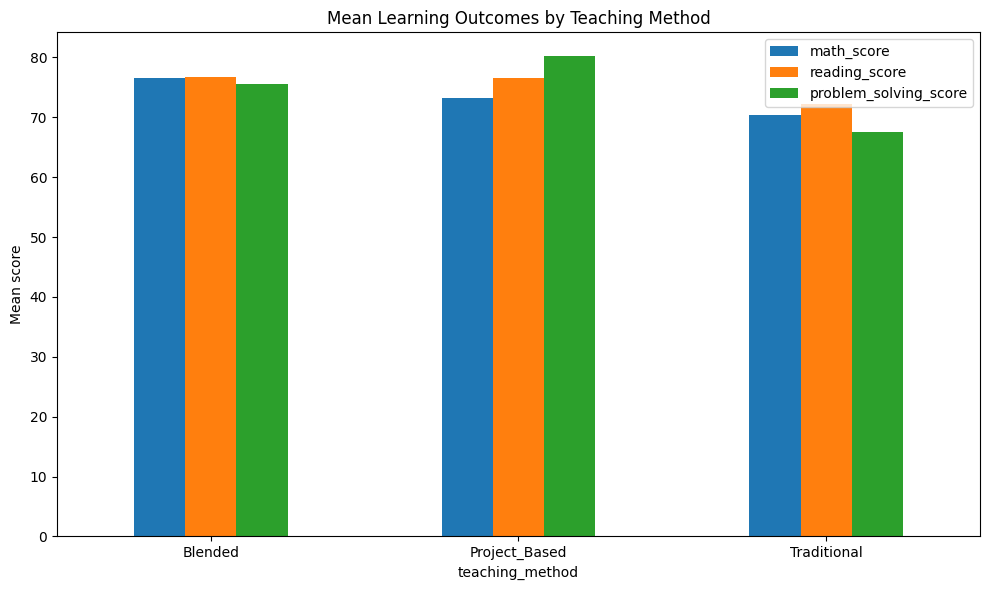

In [7]:
mean_df=df.groupby("teaching_method")[outcomes].mean()
ax=mean_df.plot(kind="bar",figsize=(10,6))
ax.set_ylabel("Mean score"); ax.set_title("Mean Learning Outcomes by Teaching Method")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 9. Relationships among Dependent Variables / 目的変数間の関係

MANOVA is useful when outcomes are related but not redundant.

目的変数間に一定の相関がありつつ、完全に同じ情報ではないか確認します。

In [8]:
df[outcomes].corr().round(3)

,math_score,reading_score,problem_solving_score
math_score,1.000,0.589,0.408
reading_score,0.589,1.000,0.534
problem_solving_score,0.408,0.534,1.000


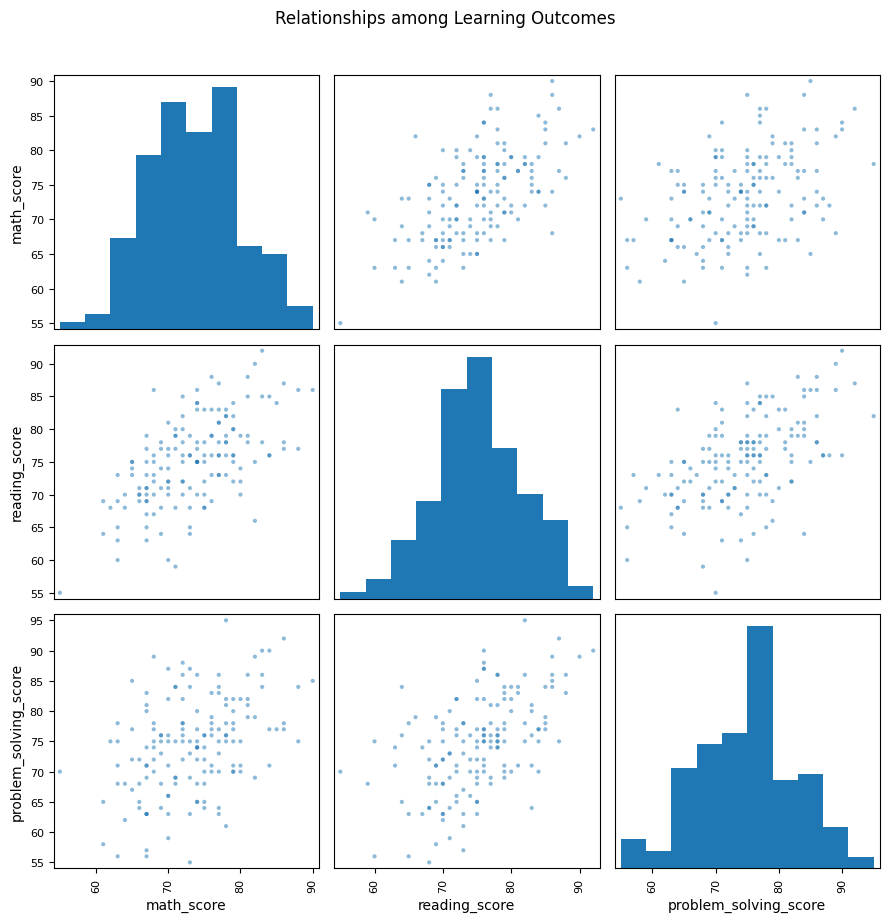

In [9]:
pd.plotting.scatter_matrix(df[outcomes],figsize=(9,9),diagonal="hist")
plt.suptitle("Relationships among Learning Outcomes",y=1.02)
plt.tight_layout(); plt.show()

## 10. Hypotheses / 仮説

**H0:** Population mean vectors are equal across teaching methods.

**H1:** At least one teaching method has a different mean vector.

平均ベクトルは `[math, reading, problem solving]` です。

## 11. Perform MANOVA / MANOVAを実行する

In [10]:
manova=MANOVA.from_formula(
    "math_score + reading_score + problem_solving_score ~ C(teaching_method)",
    data=df
)
result=manova.mv_test()
print(result)

                   Multivariate linear model
                                                                
----------------------------------------------------------------
       Intercept         Value  Num DF  Den DF   F Value  Pr > F
----------------------------------------------------------------
          Wilks' lambda  0.0117 3.0000 145.0000 4086.6277 0.0000
         Pillai's trace  0.9883 3.0000 145.0000 4086.6277 0.0000
 Hotelling-Lawley trace 84.5509 3.0000 145.0000 4086.6277 0.0000
    Roy's greatest root 84.5509 3.0000 145.0000 4086.6277 0.0000
----------------------------------------------------------------
                                                                
----------------------------------------------------------------
      C(teaching_method)   Value  Num DF  Den DF  F Value Pr > F
----------------------------------------------------------------
             Wilks' lambda 0.4896 6.0000 290.0000 20.7448 0.0000
            Pillai's trace 0.5633 6.0000 292.

## 12. Multivariate Test Statistics / 多変量検定統計量

MANOVA commonly reports:

- Pillai's Trace
- Wilks' Lambda
- Hotelling-Lawley Trace
- Roy's Greatest Root

Pillai's Trace is often regarded as relatively robust. Wilks' Lambda is also widely reported.

`C(teaching_method)` のp値が有意水準を下回れば、教育方法によって複数の学習成果をまとめた平均ベクトルに差があると判断します。

## 13. Follow-up ANOVAs / 個別ANOVA

A significant MANOVA tells us that a multivariate group difference exists, but not which outcome differs.

そこで、各目的変数について個別ANOVAを実行します。

In [11]:
anova_results=[]
for outcome in outcomes:
    model=ols(f"{outcome} ~ C(teaching_method)",data=df).fit()
    a=anova_lm(model,typ=2)
    anova_results.append({
        "outcome":outcome,
        "F":a.loc["C(teaching_method)","F"],
        "p_value":a.loc["C(teaching_method)","PR(>F)"]
    })
anova_df=pd.DataFrame(anova_results)
anova_df.round(6)

,outcome,F,p_value
0,math_score,13.793042,0.000003
1,reading_score,7.989981,0.000508
2,problem_solving_score,57.290414,0.000000


## 14. Multiple-Testing Correction / 多重検定補正

Because three follow-up tests are performed, Holm correction is applied.

3つの個別検定を行うため、Holm法でp値を補正します。

In [12]:
reject,adjusted_p,_,_=multipletests(anova_df["p_value"],alpha=.05,method="holm")
anova_df["holm_adjusted_p"]=adjusted_p
anova_df["significant_after_holm"]=reject
anova_df.round(6)

,outcome,F,p_value,holm_adjusted_p,significant_after_holm
0,math_score,13.793042,0.000003,0.000006,True
1,reading_score,7.989981,0.000508,0.000508,True
2,problem_solving_score,57.290414,0.000000,0.000000,True


## 15. Effect Size / 効果量

Statistical significance does not show the magnitude of differences.

We calculate eta squared: `η² = SS_between / SS_total`.

統計的有意差だけでなく、差の大きさをη²で確認します。

In [13]:
effects=[]
for outcome in outcomes:
    model=ols(f"{outcome} ~ C(teaching_method)",data=df).fit()
    a=anova_lm(model,typ=2)
    ssb=a.loc["C(teaching_method)","sum_sq"]; ssr=a.loc["Residual","sum_sq"]
    effects.append({"outcome":outcome,"eta_squared":ssb/(ssb+ssr)})
pd.DataFrame(effects).round(3)

,outcome,eta_squared
0,math_score,0.158
1,reading_score,0.098
2,problem_solving_score,0.438


## 16. Homogeneity of Variances / 分散の等質性

Levene's test is used as a simple univariate diagnostic. It is not a complete test of equality of covariance matrices.

Levene検定は各目的変数の分散等質性を確認する補助的な診断です。

In [14]:
levene_results=[]
for outcome in outcomes:
    samples=[g[outcome].values for _,g in df.groupby("teaching_method")]
    stat,p=levene(*samples)
    levene_results.append({"outcome":outcome,"statistic":stat,"p_value":p})
pd.DataFrame(levene_results).round(4)

,outcome,statistic,p_value
0,math_score,0.9084,0.4054
1,reading_score,1.3237,0.2693
2,problem_solving_score,0.6818,0.5073


## 17. Covariance Matrices / グループ別共分散行列

MANOVA assumes reasonably comparable covariance structures across groups.

MANOVAでは、グループ間で共分散構造が極端に異ならないことが重要です。

In [15]:
for method,group in df.groupby("teaching_method"):
    print(f"--- {method} ---")
    display(group[outcomes].cov().round(2))

--- Blended ---


,math_score,reading_score,problem_solving_score
math_score,38.90,15.71,10.12
reading_score,15.71,38.49,14.86
problem_solving_score,10.12,14.86,33.79


--- Project_Based ---


,math_score,reading_score,problem_solving_score
math_score,39.48,28.28,21.19
reading_score,28.28,53.11,26.81
problem_solving_score,21.19,26.81,40.93


--- Traditional ---


,math_score,reading_score,problem_solving_score
math_score,26.88,18.44,7.07
reading_score,18.44,30.33,13.69
problem_solving_score,7.07,13.69,33.36


## 18. Why Not Only Run Separate ANOVAs? / なぜANOVAだけではないのか

Separate ANOVAs increase the number of tests and do not directly test the joint outcome profile.

MANOVA first asks:

> Do the groups differ across the combination of outcomes?

Then follow-up tests investigate where the differences occur.

MANOVAで全体差を確認し、その後に個別ANOVAへ進むという流れが重要です。

## 19. Interpretation / 今回のデータの解釈

The simulated dataset was designed so that:

- Traditional is somewhat lower overall.
- Blended performs relatively well in Math and Reading.
- Project-Based has a particularly strong Problem-Solving profile.

これは実際の教育方法の優劣を示すものではなく、MANOVAで多変量プロフィール差を学習するためのシミュレーションです。

## 20. Assumptions and Limitations / 前提条件と限界

- observations should be independent
- dependent variables should be continuous
- approximate multivariate normality is desirable
- covariance matrices should be reasonably homogeneous
- severe multivariate outliers can affect results
- dependent variables should not be nearly perfectly correlated
- significant MANOVA does not identify which outcomes differ
- follow-up tests require multiple-testing considerations
- statistical significance does not imply practical importance
- this dataset is simulated

主な注意点は、観測の独立性、多変量正規性、共分散構造、外れ値、多重検定です。また、統計的有意差と実務的な重要性は同じではありません。

## 21. Conclusion / まとめ

Workflow:

1. Understand the dataset
2. Compare descriptive statistics
3. Examine correlations among outcomes
4. Define multivariate hypotheses
5. Perform MANOVA
6. Interpret multivariate test statistics
7. Run follow-up ANOVAs
8. Correct for multiple testing
9. Calculate effect sizes
10. Review assumptions

**Key idea:** ANOVA compares groups on one outcome; MANOVA compares groups on a combination of multiple outcomes.

**重要ポイント：** ANOVAは1つの目的変数について群を比較し、MANOVAは複数の目的変数をまとめて群を比較します。